In [43]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import math
from scipy.spatial.distance import cdist

sys.path.append(os.path.abspath('..'))

from heuristic_deterministic import data_load, run_greedy_construction
from local_search_deterministic import run_local_search
import cost_calculator

from Hyperparameter import *

In [44]:
def calculate_cost_breakdown(station_locations, allocations, robot_data):
    total_build_cost = 0.0
    total_maintain_cost = 0.0
    total_rescue_cost = 0.0
    total_charge_cost = 0.0

    station_groups = {s_id: [] for s_id in station_locations.keys()}
    for r_id, s_id in allocations.items():
        if s_id != -1 and s_id in station_groups:
            station_groups[s_id].append(r_id)

    for s_id, assigned_robots in station_groups.items():
        N_served = len(assigned_robots)
        if N_served == 0: continue

        sx, sy = station_locations[s_id]
        station_coord = np.array([[sx, sy]])

        group_data = robot_data.loc[assigned_robots]
        group_coords = group_data[['longitude', 'latitude']].values
        group_ranges = group_data['range'].values

        dist_to_station = cdist(group_coords, station_coord).flatten()

        num_chargers = math.ceil(N_served / cost_calculator.CHARGER_ROBOT_LIMIT)
        total_build_cost += cost_calculator.BUILD_COST
        total_maintain_cost += num_chargers * cost_calculator.MAINTAIN_COST

        for d, r_i in zip(dist_to_station, group_ranges):
            if d <= r_i:
                charge_amount = cost_calculator.R_MAX - r_i + d
                total_charge_cost += cost_calculator.CHARGE_COST * charge_amount
            else:
                charge_amount = cost_calculator.R_MAX - r_i
                total_charge_cost += cost_calculator.CHARGE_COST * charge_amount
                total_rescue_cost += cost_calculator.RESCUE_COST

    total_cost = total_build_cost + total_maintain_cost + total_rescue_cost + total_charge_cost
    return {
        'Build Cost': total_build_cost,
        'Maintain Cost': total_maintain_cost,
        'Rescue Cost': total_rescue_cost,
        'Charge Cost': total_charge_cost,
        'Total Cost': total_cost
    }

In [45]:
is_subset = False
target_subset = None
data_path = "../processed_data/robot_locations_range.csv"

robot_data = data_load(data_path, target_subset, is_subset)

base_ch = RESCUE_COST
percentages = [-20, -10, 0, 10, 20]
ch_test_values = [int(base_ch * (1 + p/100)) for p in percentages]
x_labels = [f"{p}% (£{ch})" for p, ch in zip(percentages, ch_test_values)]

results_breakdown = {'Build Cost': [], 'Maintain Cost': [], 'Rescue Cost': [], 'Charge Cost': [], 'Total Cost': []}
results_stations = []

In [46]:
for ch in ch_test_values:
    cost_calculator.RESCUE_COST = ch

    # old_stdout = sys.stdout
    # sys.stdout = open(os.devnull, 'w')

    # Greedy
    initial_stations, initial_allocations, _ = run_greedy_construction(robot_data)

    # Local Search
    final_stations, final_allocations = run_local_search(robot_data, initial_stations, initial_allocations)
    # sys.stdout = old_stdout

    # Perform cost breakdown calculations using the optimised final_stations
    breakdown = calculate_cost_breakdown(final_stations, final_allocations, robot_data)
    num_stations = len(final_stations)

    for key in results_breakdown.keys():
        results_breakdown[key].append(breakdown[key])
    results_stations.append(num_stations)

    print(f"Tested c_h = £{ch:<4d} | Total Cost = £{breakdown['Total Cost']:,.2f} | Stations Built = {num_stations}")

cost_calculator.RESCUE_COST = 1000

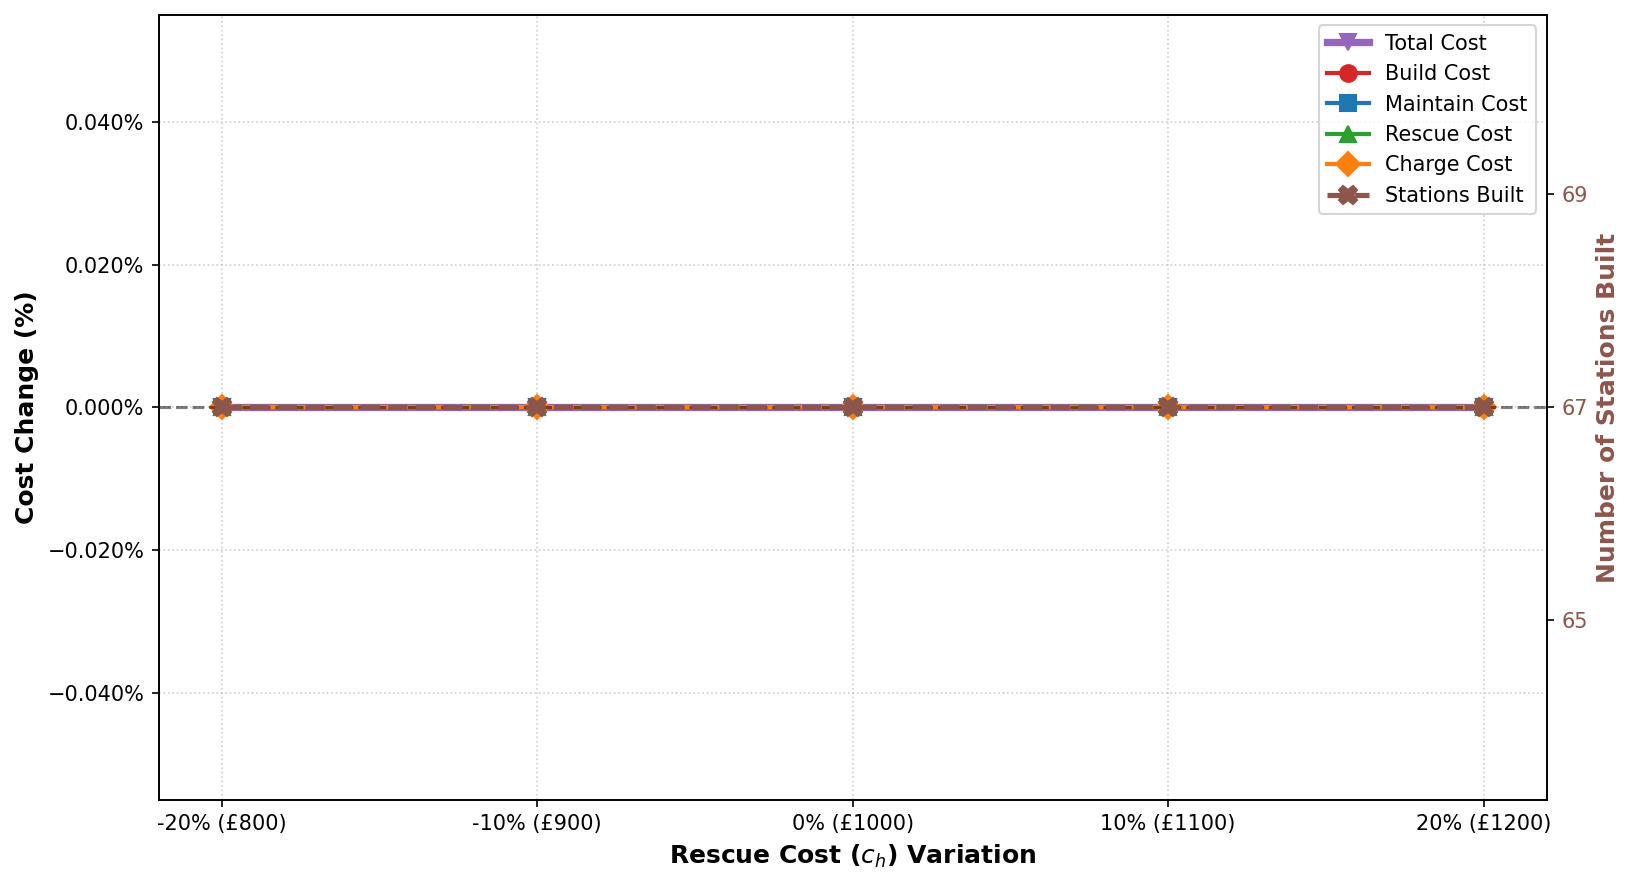

In [49]:
fig, ax1 = plt.subplots(figsize=(11, 6), dpi=150)

x = np.arange(len(percentages))

# baseline
base_idx = percentages.index(0)

# Auxiliary Function
def get_percent_change(values):
    base_val = values[base_idx]
    change = []
    for v in values:
        if base_val == 0:
            change.append(0.0 if v == 0 else np.nan)
        else:
            change.append((v - base_val) / base_val * 100)
    return change

# Define the curve styles
cost_metrics = ['Total Cost', 'Build Cost', 'Maintain Cost', 'Rescue Cost', 'Charge Cost']
colors = {'Total Cost': '#9467bd', 'Build Cost': '#d62728', 'Maintain Cost': '#1f77b4', 'Rescue Cost': '#2ca02c', 'Charge Cost': '#ff7f0e'}
markers = {'Total Cost': 'v', 'Build Cost': 'o', 'Maintain Cost': 's', 'Rescue Cost': '^', 'Charge Cost': 'D'}
linewidths = {'Total Cost': 3.5, 'Build Cost': 2, 'Maintain Cost': 2, 'Rescue Cost': 2, 'Charge Cost': 2}

handles = []
labels = []

for metric in cost_metrics:
    y_values = get_percent_change(results_breakdown[metric])
    line, = ax1.plot(x, y_values, label=metric, color=colors[metric], marker=markers[metric],
                     linewidth=linewidths[metric], linestyle='-', markersize=8)
    handles.append(line)
    labels.append(metric)

# Define the axes styles
ax1.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax1.set_xlabel('Rescue Cost ($c_h$) Variation', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cost Change (%)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(True, linestyle=':', alpha=0.6)

ax2 = ax1.twinx()
color2 = '#8c564b'
ax2.set_ylabel('Number of Stations Built', color=color2, fontsize=12, fontweight='bold')

line2, = ax2.plot(x, results_stations, label='Stations Built', color=color2, marker='X',
                  linewidth=2.5, linestyle='--', markersize=9)
ax2.tick_params(axis='y', labelcolor=color2)

y_min = min(results_stations)
y_max = max(results_stations)
if y_min == y_max:
    ax2.set_yticks([y_min - 2, y_min, y_min + 2])
else:
    ax2.set_yticks(np.arange(y_min - 1, y_max + 2, 1))

handles.append(line2)
labels.append('Stations Built')

ax1.legend(handles, labels, loc='best', frameon=True, fontsize=10)
fig.tight_layout()

# Save the figure
plt.savefig("Sensitivity_ch.pdf", format='pdf')
plt.show()

In [48]:
param_name = "ch"

# Set the target output path
output_dir = "../results/Sensitivity_Analysis/"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

csv_filename = os.path.join(output_dir, f"Sensitivity_Data_{param_name}.csv")

# Saving results
df_export = pd.DataFrame({
    'Variation_Percent': percentages,
    'Total_Cost': results_breakdown['Total Cost']
})

df_export.to_csv(csv_filename, index=False)